# BTC/USDT · PPO 强化学习训练

使用 Stable Baselines 3 (PPO) 对 1 分钟 K 线数据进行训练。

**观测特征**：EMA 偏差率、布林带位置、成交量比率、爆仓量（多/空）、RSI、MACD  
**奖励函数**：步骤收益 − 回撤惩罚（兼顾收益与风险）  
**数据来源**：PostgreSQL (OHLCV) + Binance/数据库 (爆仓)

## 1. 配置

In [ ]:
# ── 数据参数（与 crypto_kline_analysis 保持一致）────────────────
SYMBOL      = "BTC/USDT"
START_DATE  = "2026-04-09 00:00:00"
END_DATE    = "2026-04-13 00:00:00"
TIMEZONE    = "Asia/Shanghai"
DB_TABLE    = "public.crypto_kline_binance"
ONLY_CLOSED = True
LIQDATA_SOURCE = "database"           # "database" 或 "binance_api"
LIQ_TABLE      = "public.crypto_liquidation_binance"

# ── RL 超参数 ────────────────────────────────────────────────────
WINDOW_SIZE     = 30        # 滑动观测窗口（分钟数）
INITIAL_BALANCE = 10_000.0  # 初始资金（USD）
COMMISSION      = 0.001     # 单向手续费率
PENALTY_WEIGHT  = 0.05      # 回撤惩罚系数（越大越厌恶风险）
TRAIN_RATIO     = 0.8       # 训练集比例

# ── PPO 超参数 ───────────────────────────────────────────────────
TOTAL_TIMESTEPS = 1_000_000
PPO_KWARGS = dict(
    learning_rate = 3e-4,
    n_steps       = 2048,
    batch_size    = 64,
    n_epochs      = 10,
    gamma         = 0.99,
    gae_lambda    = 0.95,
    clip_range    = 0.2,
    ent_coef      = 0.005,
    vf_coef       = 0.5,
    max_grad_norm = 0.5,
)
RUN_NAME   = f"{SYMBOL.replace('/','')}__ppo"
MODEL_DIR  = "../models/saved"
LOG_DIR    = "../models/logs"
# ────────────────────────────────────────────────────────────────

## 2. 数据加载与特征工程

### 2.1 OHLCV 加载

In [ ]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import requests
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
matplotlib.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from stable_baselines3.common.vec_env import DummyVecEnv
import gymnasium as gym
from gymnasium import spaces
from pathlib import Path

from utils.db import read_ohlcv

tz = TIMEZONE
start_utc = pd.Timestamp(START_DATE, tz=tz).tz_convert("UTC").isoformat()
end_utc   = pd.Timestamp(END_DATE,   tz=tz).tz_convert("UTC").isoformat()

df_raw = read_ohlcv(SYMBOL, start=start_utc, end=end_utc,
                    table=DB_TABLE, only_closed=ONLY_CLOSED)
ts = df_raw["timestamp"]
if ts.dt.tz is None:
    ts = ts.dt.tz_localize("UTC")
df_raw["timestamp"] = ts.dt.tz_convert(tz)

print(f"OHLCV 行数  : {len(df_raw)}")
print(f"时间范围    : {df_raw['timestamp'].min()} → {df_raw['timestamp'].max()}")
df_raw.head(3)

### 2.2 爆仓数据加载

In [15]:
def _fetch_liq_binance_api(symbol: str, start_ms: int, end_ms: int) -> pd.DataFrame:
    sym, url, rows = symbol.replace("/", ""), "https://fapi.binance.com/fapi/v1/allForceOrders", []
    t = start_ms
    while t < end_ms:
        r = requests.get(url, params=dict(symbol=sym, startTime=t,
                         endTime=min(t+86_400_000, end_ms), limit=1000), timeout=15)
        r.raise_for_status()
        batch = r.json()
        if not batch: t += 86_400_000; continue
        rows.extend(batch)
        last_t = max(o["time"] for o in batch)
        t = last_t + 1 if len(batch) >= 1000 else last_t + 86_400_001
    if not rows:
        return pd.DataFrame(columns=["timestamp","side","qty","avg_price","cost"])
    df = pd.DataFrame(rows).drop_duplicates(subset=["time","side","price","origQty"])
    df["timestamp"] = pd.to_datetime(df["time"], unit="ms", utc=True)
    df["side"]      = df["side"].str.lower()
    df["qty"]       = df["executedQty"].astype(float)
    df["avg_price"] = df["averagePrice"].astype(float)
    df["cost"]      = df["qty"] * df["avg_price"]
    return df[["timestamp","side","qty","avg_price","cost"]].copy()


def _fetch_liq_database(symbol, start_utc, end_utc, table):
    from utils.db import execute
    sql = (f"SELECT liquidation_time AS timestamp, side, amount AS qty, "
           f"avg_price, cost FROM {table} "
           f"WHERE symbol=:sym AND liquidation_time>=:start AND liquidation_time<:end "
           f"ORDER BY liquidation_time ASC")
    df = execute(sql, {"sym": symbol, "start": start_utc, "end": end_utc})
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df["side"] = df["side"].str.lower()
    df[["qty","avg_price","cost"]] = df[["qty","avg_price","cost"]].astype(float)
    return df[["timestamp","side","qty","avg_price","cost"]].copy()


start_ms = int(pd.Timestamp(START_DATE, tz=TIMEZONE).tz_convert("UTC").timestamp() * 1000)
end_ms   = int(pd.Timestamp(END_DATE,   tz=TIMEZONE).tz_convert("UTC").timestamp() * 1000)

if LIQDATA_SOURCE == "binance_api":
    df_liq = _fetch_liq_binance_api(SYMBOL, start_ms, end_ms)
else:
    df_liq = _fetch_liq_database(SYMBOL, start_utc, end_utc, LIQ_TABLE)

# 聚合为1分钟
def _resample_liq(df, tz):
    li = df.loc[df["side"]=="sell"].set_index("timestamp")["cost"]
    si = df.loc[df["side"]=="buy"].set_index("timestamp")["cost"]
    ll = li.resample("1min", label="left", closed="left").sum().rename("liq_long")
    ls = si.resample("1min", label="left", closed="left").sum().rename("liq_short")
    agg = pd.concat([ll, ls], axis=1).fillna(0)
    agg.index = agg.index.tz_convert(tz)
    return agg.reset_index()

liq_1m = _resample_liq(df_liq, TIMEZONE)
print(f"爆仓订单   : {len(df_liq):,}  |  多单: {(df_liq['side']=='sell').sum():,}  空单: {(df_liq['side']=='buy').sum():,}")
print(f"1m 聚合行数: {len(liq_1m)}")

爆仓订单   : 1,998  |  多单: 938  空单: 1,060
1m 聚合行数: 3719


### 2.3 指标计算与特征合并

In [16]:
d = df_raw.copy()

# ── EMA ──────────────────────────────────────────────────────────
d["ema9"]  = d["close"].ewm(span=9,  adjust=False).mean()
d["ema21"] = d["close"].ewm(span=21, adjust=False).mean()
d["ema55"] = d["close"].ewm(span=55, adjust=False).mean()

# ── Bollinger Band (20, 2σ) ───────────────────────────────────────
d["bb_mid"]   = d["close"].rolling(20).mean()
d["bb_std"]   = d["close"].rolling(20).std()
d["bb_upper"] = d["bb_mid"] + 2 * d["bb_std"]
d["bb_lower"] = d["bb_mid"] - 2 * d["bb_std"]

# ── RSI (14) ─────────────────────────────────────────────────────
delta = d["close"].diff()
d["rsi"] = 100 - 100 / (1 + delta.clip(lower=0).rolling(14).mean()
                           / (-delta.clip(upper=0)).rolling(14).mean().replace(0, np.nan))

# ── MACD (12, 26, 9) ─────────────────────────────────────────────
ema12 = d["close"].ewm(span=12, adjust=False).mean()
ema26 = d["close"].ewm(span=26, adjust=False).mean()
d["macd"]        = ema12 - ema26
d["macd_signal"] = d["macd"].ewm(span=9, adjust=False).mean()
d["macd_hist"]   = d["macd"] - d["macd_signal"]

# ── 成交量均线 ────────────────────────────────────────────────────
d["vol_ma20"] = d["volume"].rolling(20).mean()

# ── 合并爆仓（floor merge）────────────────────────────────────────
d["_mk"]      = d["timestamp"].dt.floor("min")
liq_1m["_mk"] = liq_1m["timestamp"].dt.floor("min")
d = d.merge(liq_1m[["_mk","liq_long","liq_short"]], on="_mk", how="left").drop(columns=["_mk"])
d[["liq_long","liq_short"]] = d[["liq_long","liq_short"]].fillna(0)

d = d.dropna().reset_index(drop=True)
print(f"有效行数: {len(d)}")
d.head(3)

有效行数: 5011


,timestamp,open,high,low,close,volume,ema9,ema21,ema55,bb_mid,bb_std,bb_upper,bb_lower,rsi,macd,macd_signal,macd_hist,vol_ma20,liq_long,liq_short
0,2026-04-09 12:28:00+08:00,70838.81,70838.81,70829.99,70832.17,1.54569,70850.834590,70880.587379,70915.017255,70888.4495,43.093295,70974.636091,70802.262909,30.715630,-29.245527,-23.529061,-5.716466,6.084033,0.0,0.0
1,2026-04-09 12:29:00+08:00,70832.17,70855.04,70832.16,70838.00,7.16022,70848.267672,70876.715800,70912.266639,70882.7410,41.749075,70966.239150,70799.242850,35.734715,-28.810607,-24.585370,-4.225237,6.290577,0.0,0.0
2,2026-04-09 12:30:00+08:00,70838.00,70864.13,70838.00,70844.73,6.96382,70847.560138,70873.808000,70909.854616,70877.0960,38.604522,70954.305045,70799.886955,32.323692,-27.604665,-25.189229,-2.415436,6.533506,0.0,0.0


### 2.4 归一化特征矩阵

In [17]:
# 每个时间步的特征向量（13维，窗口化后作为观测输入）
feat = d.copy()

feat["ret_1m"]       = feat["close"].pct_change().fillna(0).clip(-0.1, 0.1)
feat["hl_ratio"]     = (feat["high"] - feat["low"]) / (feat["close"] + 1e-8)
feat["body_ratio"]   = (feat["close"] - feat["open"]) / (feat["high"] - feat["low"] + 1e-8)
feat["ema9_r"]       = (feat["ema9"]  - feat["close"]) / (feat["close"] + 1e-8)
feat["ema21_r"]      = (feat["ema21"] - feat["close"]) / (feat["close"] + 1e-8)
feat["ema55_r"]      = (feat["ema55"] - feat["close"]) / (feat["close"] + 1e-8)
feat["bb_pos"]       = ((feat["close"] - feat["bb_lower"])
                        / (feat["bb_upper"] - feat["bb_lower"] + 1e-8)).clip(0, 2)
feat["vol_ratio"]    = np.log1p(feat["volume"] / (feat["vol_ma20"] + 1e-8))
feat["liq_long_log"] = np.log1p(feat["liq_long"]) / 10
feat["liq_short_log"]= np.log1p(feat["liq_short"]) / 10
feat["rsi_norm"]     = feat["rsi"] / 100
feat["macd_norm"]    = feat["macd"] / (feat["close"] + 1e-8)
feat["macd_hist_norm"]= feat["macd_hist"] / (feat["close"] + 1e-8)

FEATURE_COLS = [
    "ret_1m", "hl_ratio", "body_ratio",
    "ema9_r", "ema21_r", "ema55_r", "bb_pos",
    "vol_ratio",
    "liq_long_log", "liq_short_log",
    "rsi_norm", "macd_norm", "macd_hist_norm",
]

feat_matrix = feat[FEATURE_COLS].ffill().fillna(0).values.astype(np.float32)
close_arr   = feat["close"].values.astype(np.float32)

print(f"特征矩阵形状 : {feat_matrix.shape}  ({len(FEATURE_COLS)} 维 × {len(feat)} 步)")
print(f"特征列       : {FEATURE_COLS}")

特征矩阵形状 : (5011, 13)  (13 维 × 5011 步)
特征列       : ['ret_1m', 'hl_ratio', 'body_ratio', 'ema9_r', 'ema21_r', 'ema55_r', 'bb_pos', 'vol_ratio', 'liq_long_log', 'liq_short_log', 'rsi_norm', 'macd_norm', 'macd_hist_norm']


## 3. 自定义交易环境

**观测空间**：`(WINDOW_SIZE × 13 + 2,)` 展平向量  
— 最近 `WINDOW_SIZE` 步的归一化特征 + `[balance_ratio, holding_ratio]` 组合状态

**动作空间**：Discrete(3) — 0=持仓, 1=全仓买入, 2=全仓卖出

**奖励函数**：  
`reward = step_return − PENALTY_WEIGHT × current_drawdown`  
— 步骤收益驱动盈利，回撤惩罚抑制风险

In [18]:
class CryptoPPOEnv(gym.Env):
    """
    1-minute crypto trading environment for SB3 PPO.

    Observation = flatten(features[t-W:t])  +  [balance_ratio, holding_ratio]
    Reward      = step_return  -  penalty_weight * drawdown
    """
    metadata = {"render_modes": []}

    def __init__(
        self,
        features: np.ndarray,   # (T, n_feat)  pre-normalised
        prices:   np.ndarray,   # (T,)  close prices for execution
        window_size:     int   = WINDOW_SIZE,
        initial_balance: float = INITIAL_BALANCE,
        commission:      float = COMMISSION,
        penalty_weight:  float = PENALTY_WEIGHT,
    ):
        super().__init__()
        self.features        = features
        self.prices          = prices
        self.window_size     = window_size
        self.initial_balance = initial_balance
        self.commission      = commission
        self.penalty_weight  = penalty_weight
        self.n_feat          = features.shape[1]

        n_obs = window_size * self.n_feat + 2
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(n_obs,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(3)  # 0=hold 1=buy 2=sell
        self._reset_state()

    # ── internal helpers ────────────────────────────────────────
    def _reset_state(self):
        self.balance    = self.initial_balance
        self.position   = 0.0
        self.peak_value = self.initial_balance
        self.step_idx   = self.window_size
        self.trades: list[dict] = []
        self.portfolio_history: list[float] = []

    def _portfolio_value(self, price: float) -> float:
        return self.balance + self.position * price

    def _get_obs(self) -> np.ndarray:
        window = self.features[self.step_idx - self.window_size : self.step_idx]
        price  = float(self.prices[self.step_idx])
        pv     = self._portfolio_value(price)
        port   = np.array([
            self.balance / self.initial_balance,
            self.position * price / self.initial_balance,
        ], dtype=np.float32)
        return np.concatenate([window.flatten(), port])

    # ── gym API ─────────────────────────────────────────────────
    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self._reset_state()
        return self._get_obs(), {}

    def step(self, action: int):
        price      = float(self.prices[self.step_idx])
        prev_value = self._portfolio_value(price)

        # ── execute action ───────────────────────────────────────
        if action == 1 and self.balance > 0:          # buy
            qty = self.balance * (1 - self.commission) / price
            self.position += qty
            self.balance   = 0.0
            self.trades.append({"step": self.step_idx, "side": "buy",  "price": price})
        elif action == 2 and self.position > 0:       # sell
            self.balance  += self.position * price * (1 - self.commission)
            self.position  = 0.0
            self.trades.append({"step": self.step_idx, "side": "sell", "price": price})

        self.step_idx += 1
        done = self.step_idx >= len(self.prices) - 1

        new_price = float(self.prices[self.step_idx])
        new_value = self._portfolio_value(new_price)
        self.portfolio_history.append(new_value)

        # ── reward = step return − drawdown penalty ──────────────
        step_ret = (new_value - prev_value) / (prev_value + 1e-8)
        if new_value > self.peak_value:
            self.peak_value = new_value
        drawdown = (self.peak_value - new_value) / (self.peak_value + 1e-8)
        reward   = float(step_ret - self.penalty_weight * drawdown)

        obs  = self._get_obs()
        info = {
            "portfolio_value": new_value,
            "balance":         self.balance,
            "position":        self.position,
            "drawdown":        drawdown,
            "n_trades":        len(self.trades),
        }
        return obs, reward, done, False, info

    def render(self):
        price = float(self.prices[self.step_idx])
        pv    = self._portfolio_value(price)
        dd    = (self.peak_value - pv) / (self.peak_value + 1e-8)
        print(f"step={self.step_idx:5d} | PV={pv:,.2f} | DD={dd:.2%} | trades={len(self.trades)}")

## 4. 数据集划分（8:2）

In [19]:
n_total = len(feat_matrix)
n_train = int(n_total * TRAIN_RATIO)
n_eval  = n_total - n_train

train_feat, eval_feat   = feat_matrix[:n_train], feat_matrix[n_train:]
train_price, eval_price = close_arr[:n_train],   close_arr[n_train:]
train_time  = feat["timestamp"].iloc[:n_train]
eval_time   = feat["timestamp"].iloc[n_train:]

print(f"总步数  : {n_total}")
print(f"训练集  : {n_train} 步  ({train_time.iloc[0]}  →  {train_time.iloc[-1]})")
print(f"验证集  : {n_eval} 步  ({eval_time.iloc[0]}  →  {eval_time.iloc[-1]})")

# 可行性检查：窗口必须 < 训练集长度
assert n_train > WINDOW_SIZE and n_eval > WINDOW_SIZE, \
    f"数据集太短，请缩小 WINDOW_SIZE 或扩大日期范围"
print("✓ 数据集检查通过")

总步数  : 5011
训练集  : 4008 步  (2026-04-09 12:28:00+08:00  →  2026-04-12 07:16:00+08:00)
验证集  : 1003 步  (2026-04-12 07:17:00+08:00  →  2026-04-12 23:59:00+08:00)
✓ 数据集检查通过


## 5. SB3 PPO 训练

奖励指标同时考虑：
- **收益**：`step_return = ΔPV / PV`
- **风险**：`−PENALTY_WEIGHT × drawdown`（当前回撤越大惩罚越重）

In [20]:
from pathlib import Path

Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)
Path(LOG_DIR).mkdir(parents=True, exist_ok=True)

def make_train_env():
    env = CryptoPPOEnv(train_feat, train_price)
    return Monitor(env)

def make_eval_env():
    env = CryptoPPOEnv(eval_feat, eval_price)
    return Monitor(env)

train_vec = DummyVecEnv([make_train_env])
eval_vec  = DummyVecEnv([make_eval_env])

callbacks = [
    EvalCallback(
        eval_vec,
        best_model_save_path=f"{MODEL_DIR}/{RUN_NAME}",
        log_path=f"{LOG_DIR}/{RUN_NAME}",
        eval_freq=10_000,
        n_eval_episodes=1,
        deterministic=True,
        render=False,
        verbose=1,
    ),
    CheckpointCallback(
        save_freq=50_000,
        save_path=f"{MODEL_DIR}/{RUN_NAME}/checkpoints",
        name_prefix=RUN_NAME,
    ),
]

model = PPO(
    "MlpPolicy",
    train_vec,
    tensorboard_log=LOG_DIR,
    verbose=1,
    **PPO_KWARGS,
)

print(f"观测维度   : {model.observation_space.shape}")
print(f"训练步数   : {TOTAL_TIMESTEPS:,}")
print(f"TensorBoard: tensorboard --logdir {LOG_DIR}")

Using cuda device
观测维度   : (392,)
训练步数   : 300,000
TensorBoard: tensorboard --logdir ../models/logs


/home/davidlyu/projects/GinkgoBrain/.venv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [21]:
model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=callbacks,
    tb_log_name=RUN_NAME,
    progress_bar=True,
)
model.save(f"{MODEL_DIR}/{RUN_NAME}/final")
print(f"模型已保存至 {MODEL_DIR}/{RUN_NAME}/final.zip")

Logging to ../models/logs/BTCUSDT__ppo_2


/home/davidlyu/projects/GinkgoBrain/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

-----------------------------
| time/              |      |
|    fps             | 972  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 3.98e+03    |
|    ep_rew_mean          | -88.8       |
| time/                   |             |
|    fps                  | 740         |
|    iterations           | 2           |
|    time_elapsed         | 5           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010975358 |
|    clip_fraction        | 0.0572      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -5.36       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0337     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.012

Eval num_timesteps=10000, episode_reward=-7.45 +/- 0.00

Episode length: 972.00 +/- 0.00

...

Episode length: 972.00 +/- 0.00

-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 972         |
|    mean_reward          | -0.6        |
| time/                   |             |
|    total_timesteps      | 300000      |
| train/                  |             |
|    approx_kl            | 0.019586317 |
|    clip_fraction        | 0.128       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.326      |
|    explained_variance   | 0.987       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0449     |
|    n_updates            | 1460        |
|    policy_gradient_loss | -0.0263     |
|    value_loss           | 0.000338    |
-----------------------------------------


New best mean reward!

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3.98e+03 |
|    ep_rew_mean     | -40.5    |
| time/              |          |
|    fps             | 603      |
|    iterations      | 147      |
|    time_elapsed    | 499      |
|    total_timesteps | 301056   |
---------------------------------


模型已保存至 ../models/saved/BTCUSDT__ppo/final.zip


## 6. 回测评估

使用验证集运行确定性策略（`explore=False`），评估以下指标：

| 指标 | 说明 |
|---|---|
| 总收益率 | 最终资产 / 初始资产 − 1 |
| 最大回撤 | max((peak − PV) / peak) |
| 夏普比率 | 步均收益 / 步均波动 × √(365×24×60) |
| 交易次数 | 买入 + 卖出信号总数 |

In [22]:
# 加载最佳模型（EvalCallback 保存）
best_path = f"{MODEL_DIR}/{RUN_NAME}/best_model"
eval_model = PPO.load(best_path)
print(f"加载模型: {best_path}.zip")

# 确定性回测
eval_env_raw = CryptoPPOEnv(eval_feat, eval_price)
obs, _ = eval_env_raw.reset()
done = False
while not done:
    action, _ = eval_model.predict(obs, deterministic=True)
    obs, reward, done, _, info = eval_env_raw.step(int(action))

pv_curve = np.array(eval_env_raw.portfolio_history)
trades   = eval_env_raw.trades
prices_eval = eval_price[WINDOW_SIZE + 1:]  # 对齐 pv_curve（env 第一步后才写入 pv）

# ── 指标计算 ───────────────────────────────────────────────────
total_return = pv_curve[-1] / INITIAL_BALANCE - 1
peak = np.maximum.accumulate(pv_curve)
drawdowns = (peak - pv_curve) / (peak + 1e-8)
max_dd = drawdowns.max()

step_rets = np.diff(pv_curve) / (pv_curve[:-1] + 1e-8)
sharpe = (step_rets.mean() / (step_rets.std() + 1e-8)) * np.sqrt(365 * 24 * 60)

bh_return = eval_price[-1] / eval_price[WINDOW_SIZE] - 1  # buy-and-hold baseline

print(f"{'═'*40}")
print(f"  验证集回测结果")
print(f"{'═'*40}")
print(f"  总收益率   : {total_return:+.2%}")
print(f"  买入持有   : {bh_return:+.2%}  (baseline)")
print(f"  最大回撤   : {max_dd:.2%}")
print(f"  夏普比率   : {sharpe:.2f}")
print(f"  交易次数   : {len(trades)}")
print(f"{'═'*40}")

加载模型: ../models/saved/BTCUSDT__ppo/best_model.zip
════════════════════════════════════════
  验证集回测结果
════════════════════════════════════════
  总收益率   : -2.86%
  买入持有   : -3.03%  (baseline)
  最大回撤   : 2.94%
  夏普比率   : -101.51
  交易次数   : 30
════════════════════════════════════════


/tmp/ipykernel_3564609/580920463.py:56: UserWarning: Glyph 36164 (\N{CJK UNIFIED IDEOGRAPH-8D44}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3564609/580920463.py:56: UserWarning: Glyph 20135 (\N{CJK UNIFIED IDEOGRAPH-4EA7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3564609/580920463.py:56: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3564609/580920463.py:56: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3564609/580920463.py:56: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3564609/580920463.py:56: UserWarning: Glyph 30053 (\N{CJK UNIFIED IDEOGRAPH-7565}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3564609/580920463.py:56: UserWarning: Glyph 20080 (\N{CJK UNIFIED I

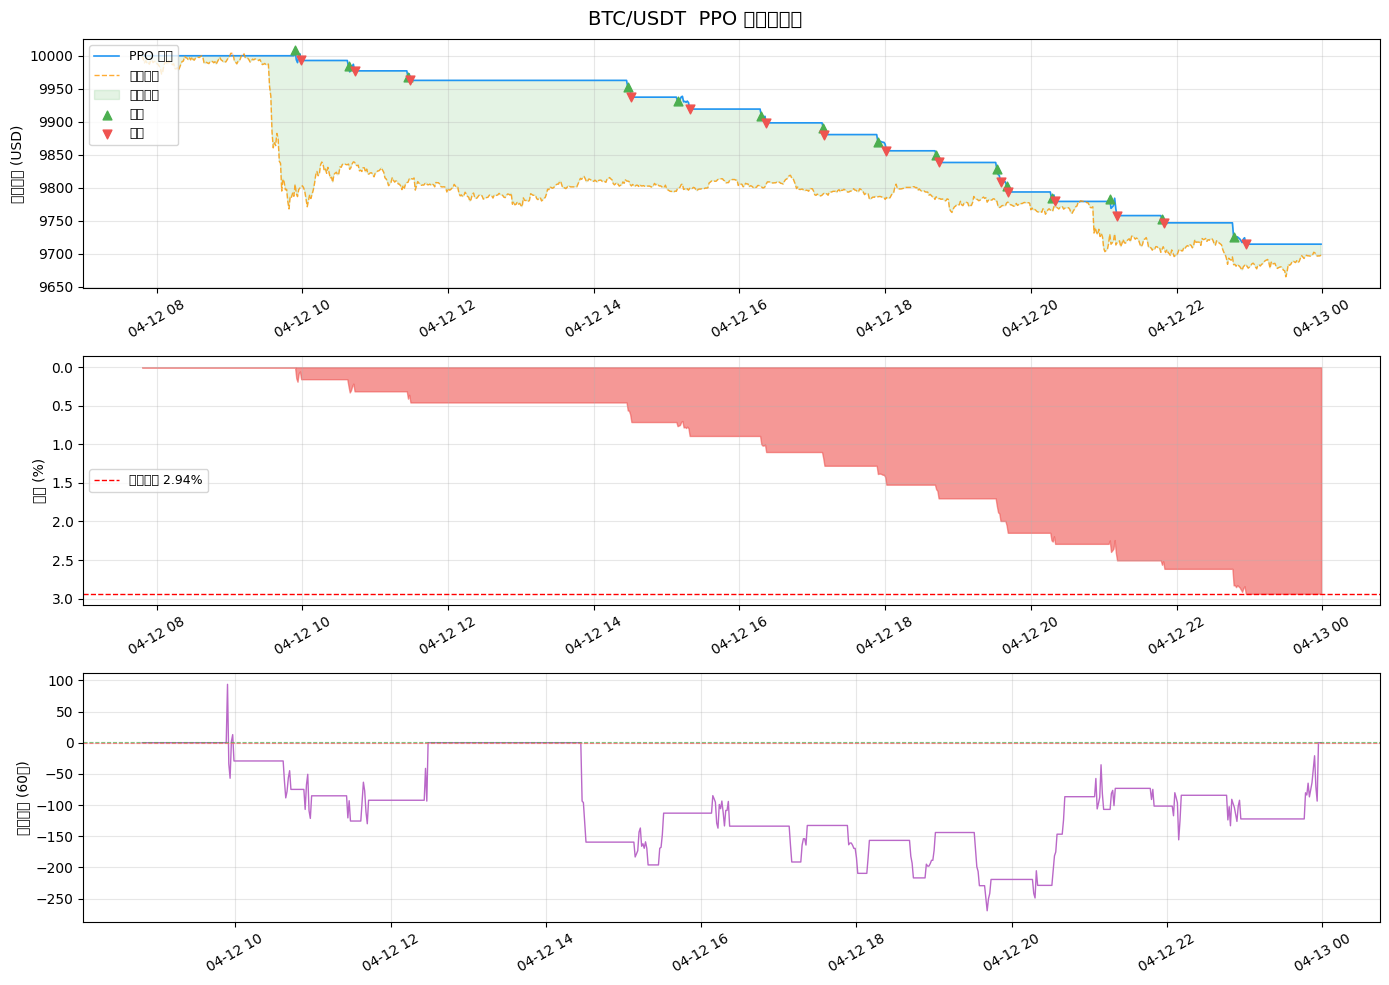

图表已保存


In [23]:
# ── 可视化 ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
fig.suptitle(f"{SYMBOL}  PPO 验证集回测", fontsize=14)

ts_eval = eval_time.iloc[WINDOW_SIZE + 1:].reset_index(drop=True)

# Row 1: 资产曲线 vs 买入持有
bh_curve = INITIAL_BALANCE * (prices_eval / prices_eval[0])
ax0 = axes[0]
ax0.plot(ts_eval, pv_curve, label="PPO 策略", color="#2196f3", linewidth=1.2)
ax0.plot(ts_eval, bh_curve, label="买入持有", color="#ff9800", linewidth=1, linestyle="--", alpha=0.8)
ax0.fill_between(ts_eval, pv_curve, bh_curve,
                 where=pv_curve >= bh_curve, alpha=0.15, color="#4caf50", label="策略超额")
ax0.fill_between(ts_eval, pv_curve, bh_curve,
                 where=pv_curve < bh_curve,  alpha=0.15, color="#ef5350")
ax0.set_ylabel("资产价值 (USD)")
ax0.legend(loc="upper left", fontsize=9)
ax0.grid(True, alpha=0.3)

# 标注买卖点
buy_steps  = [t["step"] - WINDOW_SIZE for t in trades if t["side"] == "buy"  and t["step"] - WINDOW_SIZE < len(ts_eval)]
sell_steps = [t["step"] - WINDOW_SIZE for t in trades if t["side"] == "sell" and t["step"] - WINDOW_SIZE < len(ts_eval)]
if buy_steps:
    ax0.scatter(ts_eval.iloc[buy_steps],  pv_curve[buy_steps],
                color="#4caf50", marker="^", s=40, zorder=5, label="买入")
if sell_steps:
    ax0.scatter(ts_eval.iloc[sell_steps], pv_curve[sell_steps],
                color="#ef5350", marker="v", s=40, zorder=5, label="卖出")
ax0.legend(loc="upper left", fontsize=9)

# Row 2: 回撤曲线
ax1 = axes[1]
ax1.fill_between(ts_eval, drawdowns * 100, alpha=0.6, color="#ef5350")
ax1.axhline(max_dd * 100, color="red", linestyle="--", linewidth=1,
            label=f"最大回撤 {max_dd:.2%}")
ax1.set_ylabel("回撤 (%)")
ax1.invert_yaxis()
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Row 3: 滚动夏普（60步窗口）
roll_w = 60
roll_ret  = pd.Series(step_rets)
roll_sharpe = (roll_ret.rolling(roll_w).mean()
               / (roll_ret.rolling(roll_w).std() + 1e-8)) * np.sqrt(365 * 24 * 60)
ax2 = axes[2]
ax2.plot(ts_eval.iloc[1:], roll_sharpe, color="#ba68c8", linewidth=1)
ax2.axhline(0,   color="white",   linestyle="--", linewidth=0.8, alpha=0.5)
ax2.axhline(1,   color="#4caf50", linestyle="--", linewidth=0.8, alpha=0.7)
ax2.axhline(-1,  color="#ef5350", linestyle="--", linewidth=0.8, alpha=0.7)
ax2.set_ylabel(f"滚动夏普 ({roll_w}步)")
ax2.grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/{RUN_NAME}_backtest.png", dpi=120, bbox_inches="tight")
plt.show()
print("图表已保存")